# 👩‍💻 Seasonal-Trend Decomposition of Climatic Temperature Series Analysis
## 📋 Overview
In this lab, you will analyze daily minimum temperature data using time series decomposition techniques. You'll load historical temperature data, prepare it for analysis, visualize the time series, and decompose it into its trend, seasonal, and residual components. This type of analysis is crucial for understanding patterns in time-dependent data, which can inform business decisions like inventory management, resource planning, and forecasting.
## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Load and prepare time series data for analysis
- Visualize time series data to identify patterns
- Apply seasonal decomposition to extract trend, seasonal, and residual components
- Interpret decomposition results to derive actionable insights

## 🚀 Starting Point
Access the starter code given below.

Required tools/setup:

- Python 3.x
- pandas
- matplotlib
- statsmodels

Make sure to have a basic understanding of time series data concepts from previous lectures.

In [1]:
# Starter code - imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

## Task 1: Data Loading and Exploration
**Context:** Before analyzing any time series, we need to understand its structure and basic properties.

**Steps:**

1. Load the temperature dataset using pandas:

    - Use `pd.read_csv()` with appropriate parameters
    - Set the 'Date' column as the index with `parse_dates=True`


2. Explore the dataset:

    - Display the first few rows using `.head()`
    - Examine the data information using `.info()`
    - Check for missing values using `.isnull().sum()`

In [2]:
# Load the dataset
data = pd.read_csv('daily-minimum-temperatures-in-me.csv', index_col='Date', parse_dates=True)

# Explore the dataset
# YOUR CODE HERE

print("Shape of Dataset: ", data.shape)

print("---------- Top Five Rows of Dataset ----------")
display(data.head())

print("---------- Information of Dataset ----------")
print(data.info())

print("---------- Summary of Dataset ----------")
display(data.describe().T)

Shape of Dataset:  (3650, 1)
---------- Top Five Rows of Dataset ----------


,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


---------- Information of Dataset ----------
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Daily minimum temperatures  3650 non-null   object
dtypes: object(1)
memory usage: 57.0+ KB
None
---------- Summary of Dataset ----------


,count,unique,top,freq
Daily minimum temperatures,3650,230,11,51


**💡 Tip:** When loading time series data, always check the data type of your date column and ensure it's properly parsed as datetime.

## Task 2: Data Preprocessing
**Context:** Real-world time series data often contains missing or invalid values that need to be addressed.

**Steps:**

1. Convert temperature column to numeric:

    - Use `pd.to_numeric()` with appropriate error handling
    

2. Handle missing values:

    - Identify an appropriate interpolation method
    - Use `.interpolate()` to fill missing values

In [3]:
# Handle data types and missing values
# YOUR CODE HERE

# Convert the '#Daily minimum temperatures' column to numeric
data['Daily minimum temperatures'] = pd.to_numeric(data['Daily minimum temperatures'], errors='coerce')

# Handle missing values by interpolation before decomposition
# Linear interpolation is used here, other methods like 'spline', 'polynomial' can also be considered
data['Daily minimum temperatures'] = data['Daily minimum temperatures'].interpolate(method='linear')

data.isnull().sum()

Daily minimum temperatures    0
dtype: int64

**⚙️ Test Your Work:**

- Check for any remaining missing values with `data.isnull().sum()`
- The output should show zero missing values

## Task 3: Time Series Visualization
**Context:** Visualization helps identify patterns, trends, and potential anomalies in time series data.

**Steps:**

1. Create a line plot of the temperature data:

    - Use the `.plot()` method from pandas
    - Add appropriate title, x-label, and y-label using matplotlib functions
    - Display the plot using `plt.show()`

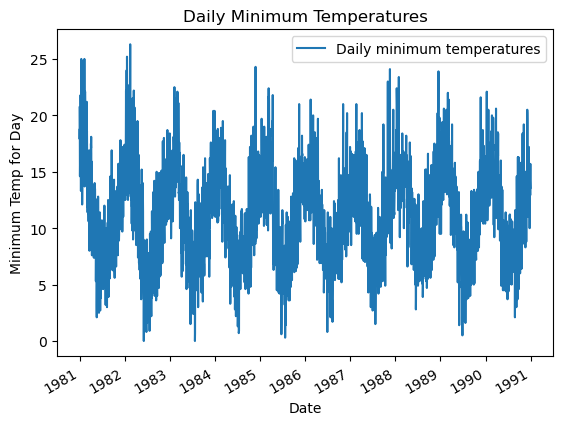

In [4]:
# Visualize the time series
# YOUR CODE HERE

data.plot()
plt.title('Daily Minimum Temperatures')
plt.ylabel('Minimum Temp for Day')
plt.xlabel('Date')
plt.show()

**💡 Tip:** Look for patterns in your visualization - are there obvious seasonal patterns or trends?

## Task 4: Seasonal Decomposition
**Context:** Breaking down a time series into its components reveals underlying patterns that drive the data.

**Steps:**

1. Apply seasonal decomposition:

    - Use `seasonal_decompose()` from statsmodels
    - Choose an appropriate model ('additive' or 'multiplicative')
    - Set the period parameter based on the data frequency (hint: for daily data with yearly patterns, use 365)

In [5]:
# Perform Seasonal Decomposition
# YOUR CODE HERE

decomposition = seasonal_decompose(data['Daily minimum temperatures'], model='additive', period=365)

## Task 5: Analyzing Decomposition Results
**Context:** The individual components from decomposition provide valuable insights about different aspects of the time series.

**Steps:**

1. Visualize decomposition components:

    - Use the `.plot()` method of the decomposition object
    - Display the plot using `plt.show()`
    
    
2. Analyze the components:

    - Examine the trend component for long-term patterns
    - Study the seasonal component for recurring patterns
    - Look at the residual component for anomalies

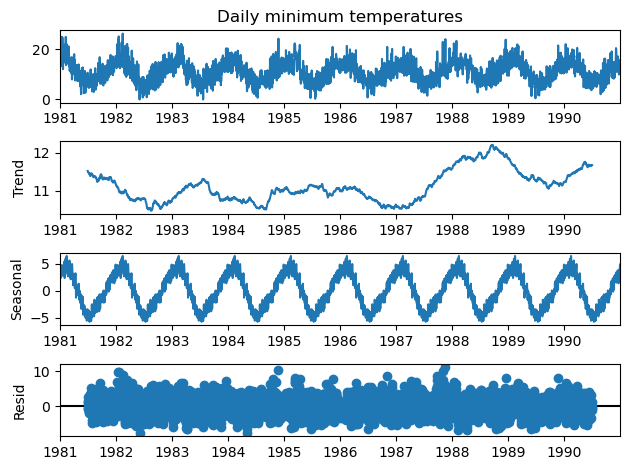

In [6]:
# Visualize and analyze decomposition components
# YOUR CODE HERE
decomposition.plot()
plt.show()

**⚙️ Test Your Work:**

- You should see four plots: original data, trend, seasonal, and residual components
- The seasonal component should show a clear yearly pattern

## ✅ Success Checklist
- Data is loaded correctly with dates as the index
- Missing values are properly handled
- Time series visualization is created with proper labels
- Seasonal decomposition is correctly applied
- Decomposition components are visualized and analyzed
- Program runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Date parsing errors when loading the data

**Solution:** Ensure you're using `parse_dates=True` and set the index correctly with `index_col='Date'`

**Problem:** Error during seasonal decomposition

**Solution:** Check that there are no missing values in your data before decomposition and that you've set an appropriate period parameter


## 🔑 Key Points
- Time series decomposition helps separate the underlying patterns from noise
- Seasonal patterns in temperature data typically follow yearly cycles
- Interpolation is a common technique for handling missing values in time series data
- Understanding each component can help make better predictions and business decisions

## 💻 Exemplar Solution

<details>

<summary><strong>Click HERE to see an exemplar solution</strong></summary>    
    
```python
# Starter code - imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

# Load and explore the dataset
data = pd.read_csv('daily-minimum-temperatures-in-me.csv', index_col='Date', parse_dates=True)
# Convert the '#Daily minimum temperatures' column to numeric
data['Daily minimum temperatures'] = pd.to_numeric(data['Daily minimum temperatures'], errors='coerce')

# Handle missing values by interpolation before decomposition
# Linear interpolation is used here, other methods like 'spline', 'polynomial' can also be considered
data['Daily minimum temperatures'] = data['Daily minimum temperatures'].interpolate(method='linear')

print(data.head())
print(data.info())

# Visualize the time series
data.plot()
plt.title('Daily Minimum Temperatures')
plt.ylabel('Minimum Temp for Day')
plt.xlabel('Date')
plt.show()

# Perform Seasonal Decomposition
decomposition = seasonal_decompose(data['Daily minimum temperatures'], model='additive', period=365)

# Visualize and analyze each component
decomposition.plot()
plt.show()

# Reflect on the long-term trends and seasonality
# Document insights that could guide decision-making
    
``` 